In [ ]:
#  PROJECT ON Fashion MNIST Image Classification using Fully Connected Neural Network (FCNN)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD

In [2]:
# Load dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Display dataset shapes
print("Shape of images from training data :", X_train.shape)
print("Shape of labels from training data :", y_train.shape)

print("Shape of images from test data:", X_test.shape)
print("Shape of labels from test data :", y_test.shape)

Shape of images from training data : (60000, 28, 28)
Shape of labels from training data : (60000,)
Shape of images from test data: (10000, 28, 28)
Shape of labels from test data : (10000,)


In [3]:
# Define Class Names

class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

In [11]:
# Visualizing Distribution of different fashion items

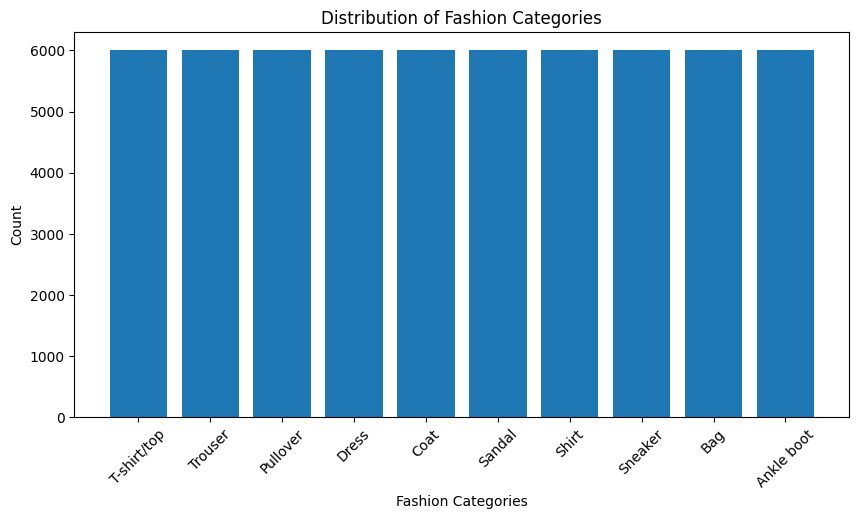

In [4]:
unique, counts = np.unique(y_train, return_counts=True)


plt.figure(figsize=(10,5))

plt.bar(class_names, counts)

plt.title("Distribution of Fashion Categories")
plt.xlabel("Fashion Categories")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# Normalizing the Image Pixel Values

In [5]:

X_train = X_train / 255.0
X_test = X_test / 255.0



In [6]:
print("Minimum Pixel Value of Image in training data:", X_train.min()) 
print("Maximum Pixel Value of Image in training data :", X_train.max())

print("\nMinimum Pixel Value of Image in test data:", X_test.min()) 
print("Maximum Pixel Value of Image in test data :", X_test.max())

Minimum Pixel Value of Image in training data: 0.0
Maximum Pixel Value of Image in training data : 1.0

Minimum Pixel Value of Image in test data: 0.0
Maximum Pixel Value of Image in test data : 1.0


#  Converting labels to one-hot encoded vectors

In [7]:
y_train_encoded = to_categorical(y_train, 10)
y_test_encoded = to_categorical(y_test, 10)

print("Original Label :", y_train[0])
print("One Hot Encoded Label :", y_train_encoded[0])

Original Label : 9
One Hot Encoded Label : [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [8]:
model = Sequential()

# Input Layer 
model.add(Input(shape=(28, 28)))


# Flatten Layer 
model.add(Flatten())

# Hidden Dense Layer 1 
model.add(Dense(256, activation='relu'))

# Hidden Dense Layer 2 
model.add(Dense(128, activation='relu'))

# Hidden Dense Layer 3 
model.add(Dense(64, activation='relu'))

# Output Layer
model.add(Dense(10, activation='softmax'))

In [9]:
#  Compile the Model

model.compile(
    optimizer=SGD(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
# Display Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
 # ============================================
# TRAINING THE MODEL
# ============================================

history = model.fit(
    X_train,
    y_train_encoded, 
    epochs=10,
    batch_size=32, 
    validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7461 - loss: 0.7570 - val_accuracy: 0.8143 - val_loss: 0.5210
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8294 - loss: 0.4883 - val_accuracy: 0.8399 - val_loss: 0.4571
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8448 - loss: 0.4376 - val_accuracy: 0.8482 - val_loss: 0.4275
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8554 - loss: 0.4103 - val_accuracy: 0.8547 - val_loss: 0.4079
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8636 - loss: 0.3877 - val_accuracy: 0.8597 - val_loss: 0.3959
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8675 - loss: 0.3709 - val_accuracy: 0.8618 - val_loss: 0.3888
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8729 - loss: 0.3549 - val_accuracy: 0.8669 - val_loss: 0.3752
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8759 - loss: 0.3424 - 

 # ============================================
# EVALUATING MODEL PERFORMANCE USING TRAINING DATA 
# ============================================

In [12]:

train_loss, train_accuracy = model.evaluate(X_train, y_train_encoded)

print(" Loss value for training data :", train_loss)
print(" Accuracy score for trainingt data:", train_accuracy)



1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8840 - loss: 0.3226
 Loss value for training data : 0.32262086868286133
 Accuracy score for trainingt data: 0.8840000033378601


 # ============================================
# EVALUATING MODEL PERFORMANCE USING VALIDATION SET OR TEST DATA 
# ============================================

In [13]:

test_loss, test_accuracy = model.evaluate(X_test, y_test_encoded)

print(" Loss value for test data:", test_loss)
print(" Accuracy score for test data:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8650 - loss: 0.3794
 Loss value for test data: 0.37944456934928894
 Accuracy score for test data: 0.8650000095367432


# ===================================================================================
# # Plotting Graph of Accuracy values obtained from Training data and Validation data
# =======================================================================================

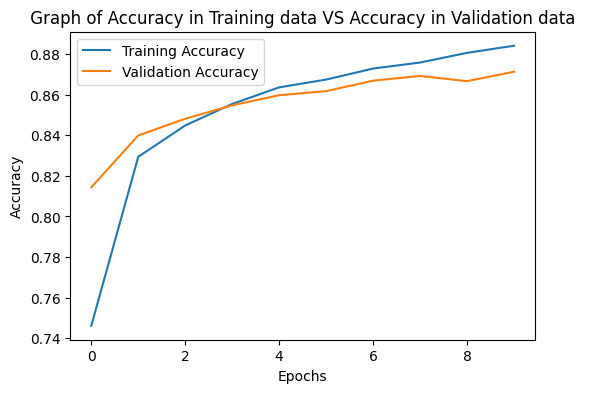

In [14]:


plt.figure(figsize=(6, 4))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.title(" Graph of Accuracy in Training data VS Accuracy in Validation data ")

plt.legend()

plt.show()

In [15]:
 # ============================================
# SAVING TRAINED MODEL
# ============================================

model.save("fashion_mnist_model.keras")

print("Model Saved Successfully")

Model Saved Successfully


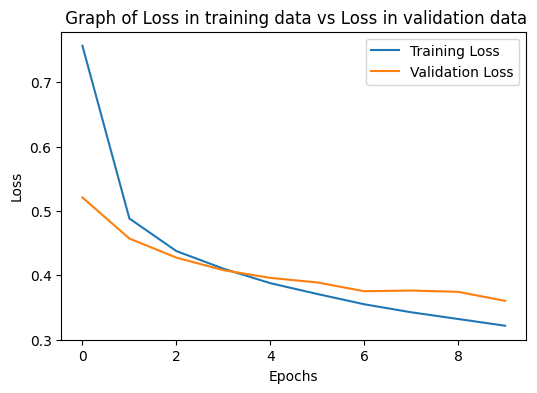

In [16]:
# ==========================================================================
# Plotting Graph of loss values obtained from Training data and Validation data
# =============================================================================

plt.figure(figsize=(6,4))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title(" Graph of Loss in training data vs Loss in validation data")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [17]:
# Predict probabilities
predictions = model.predict(X_test)

# Convert probabilities into class labels
predicted_classes = np.argmax(predictions, axis=1)



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [18]:

print("Predicted Class :", predicted_classes[0])
print("Actual Class :", y_test[0])


Predicted Class : 9
Actual Class : 9


In [19]:
print("Predicted Label or name :", class_names[predicted_classes[0]])
print("Actual Label or name :", class_names[y_test[0]])

Predicted Label or name : Ankle boot
Actual Label or name : Ankle boot


# Displaying Test data Images with Predicted label and Actual Labels

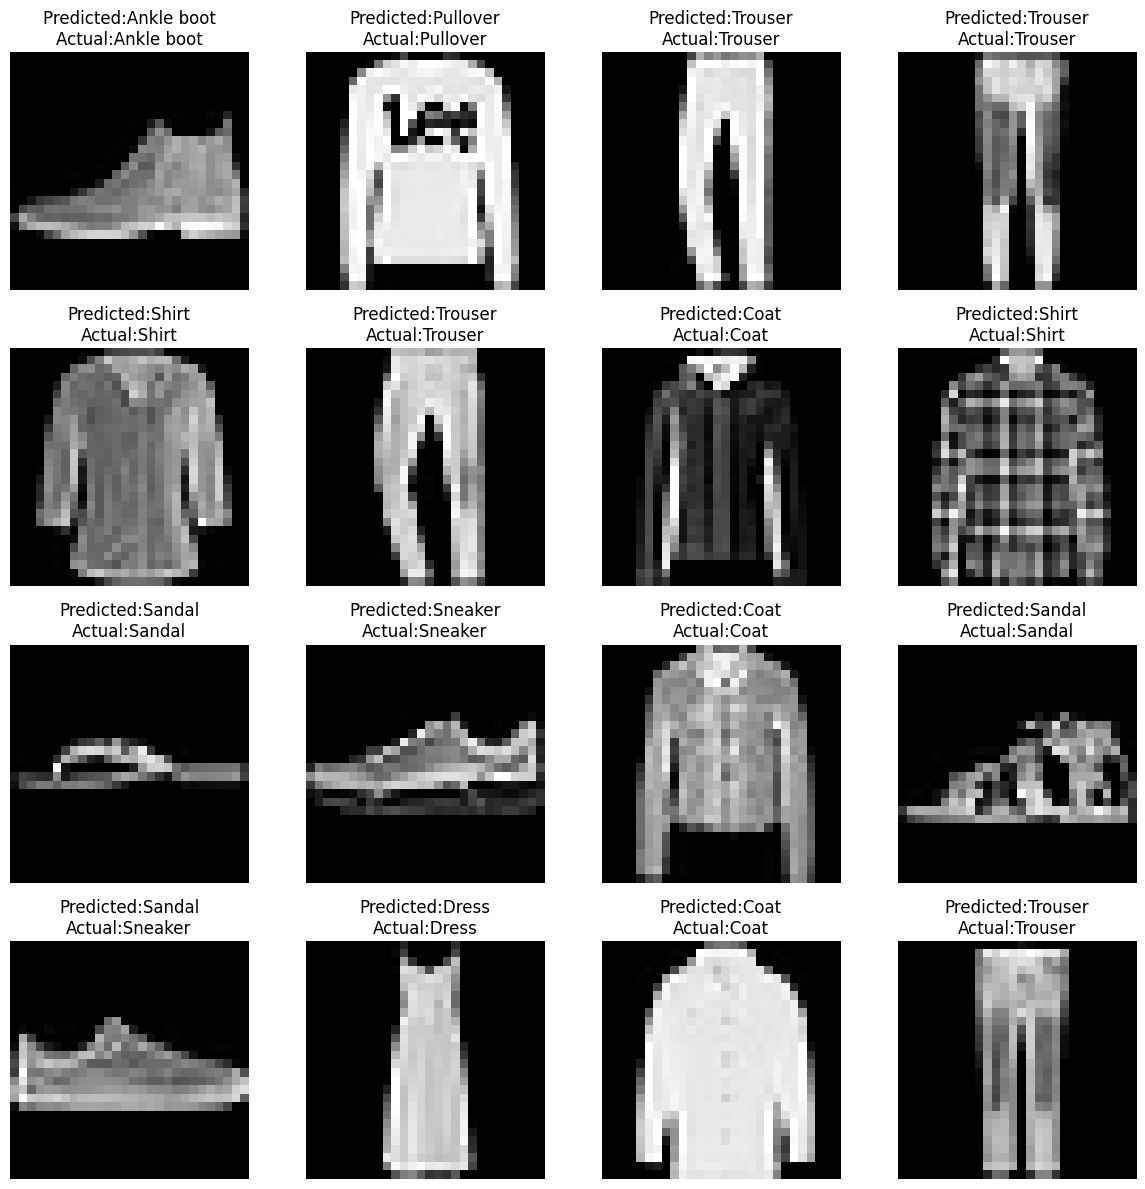

In [20]:
plt.figure(figsize=(12,12))

for i in range(16):
    
    plt.subplot(4,4,i+1)
    
    plt.imshow(X_test[i], cmap='gray')
    
    predicted_label = class_names[predicted_classes[i]]
    actual_label = class_names[y_test[i]]
    
    plt.title(f"Predicted:{predicted_label}\nActual:{actual_label}")
    
    plt.axis('off')

plt.tight_layout()
plt.show()

In [38]:
print("""
The Fully Connected Neural Network (FCNN) was successfully built and trained
using the Fashion MNIST dataset.

The model was able to classify different fashion categories with good accuracy.
Training and validation graphs were used to analyze model performance and
identify possible overfitting or underfitting.
""")


The Fully Connected Neural Network (FCNN) was successfully built and trained
using the Fashion MNIST dataset.

The model was able to classify different fashion categories with good accuracy.
Training and validation graphs were used to analyze model performance and
identify possible overfitting or underfitting.



# Save the trained model as model.pkl for deployment

In [21]:

import pickle

with open("model.pkl", "wb") as file:
    pickle.dump(model, file)

print("model.pkl saved successfully")

model.pkl saved successfully


# Verify the saved deployment model file

In [22]:

from pathlib import Path

model_path = Path("model.pkl")
print("Model file:", model_path)
print("Model file exists:", model_path.exists())
if model_path.exists():
    print("Model file size (bytes):", model_path.stat().st_size)

Model file: model.pkl
Model file exists: True
Model file size (bytes): 998466
